56
163


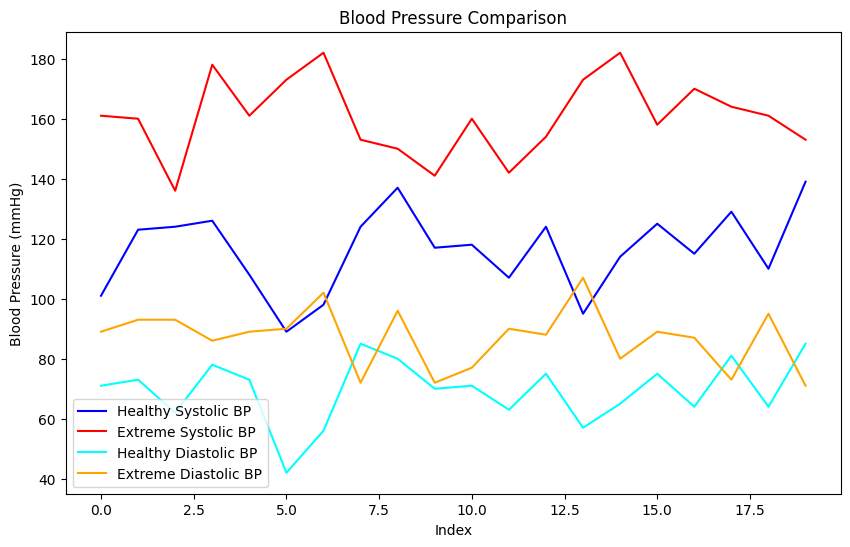

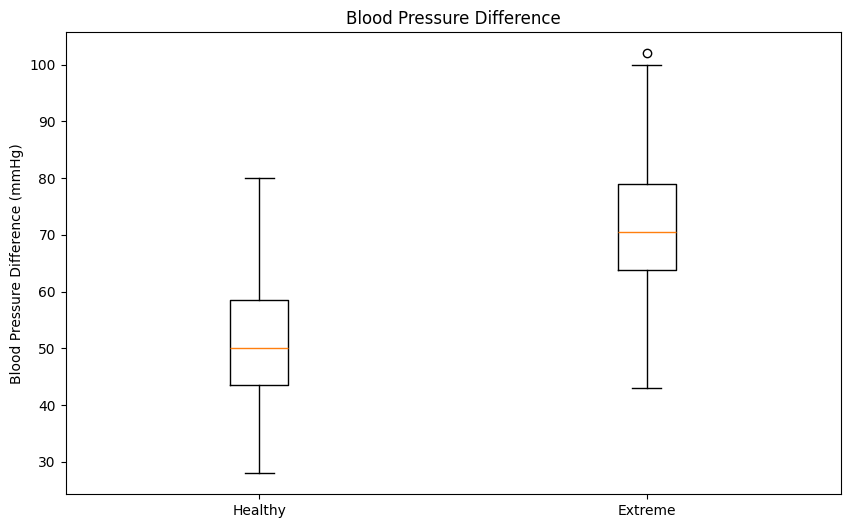

In [13]:
import pandas as pd
file_path = 'datasets/Test_Data.csv'
data = pd.read_csv(file_path)

# Add new features
data['Blood Pressure Difference'] = data['Systolic Blood Pressure(mmHg)'] - data['Diastolic Blood Pressure(mmHg)']

# Identify patients with Stage 2 Hypertension
data['Stage 2 Hypertension'] = (data['Systolic Blood Pressure(mmHg)'] >= 140) | (data['Diastolic Blood Pressure(mmHg)'] >= 90)

extreme = data[data['Stage 2 Hypertension'] == True]
output_path = 'extreme.csv'
extreme.to_csv(output_path, index=False)
print(len(extreme))

# Identify healthy patients
healthy_patients = data[data['Stage 2 Hypertension'] == False]
output_path = 'datasets/healthy_patients.csv'
healthy_patients.to_csv(output_path, index=False)
print(len(healthy_patients))

# Plotting

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.plot(range(20), healthy_patients[:20]['Systolic Blood Pressure(mmHg)'], label="Healthy Systolic BP", color='blue')
plt.plot(range(20), extreme[:20]['Systolic Blood Pressure(mmHg)'], label="Extreme Systolic BP", color='red')

plt.plot(range(20), healthy_patients[:20]['Diastolic Blood Pressure(mmHg)'], label="Healthy Diastolic BP", color='cyan')
plt.plot(range(20), extreme[:20]['Diastolic Blood Pressure(mmHg)'], label="Extreme Diastolic BP", color='orange')

plt.title("Blood Pressure Comparison")
plt.xlabel("Index")
plt.ylabel("Blood Pressure (mmHg)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot([healthy_patients['Blood Pressure Difference'],
             extreme['Blood Pressure Difference']],
            tick_labels=['Healthy', 'Extreme'])
plt.title("Blood Pressure Difference")
plt.ylabel("Blood Pressure Difference (mmHg)")
plt.show()


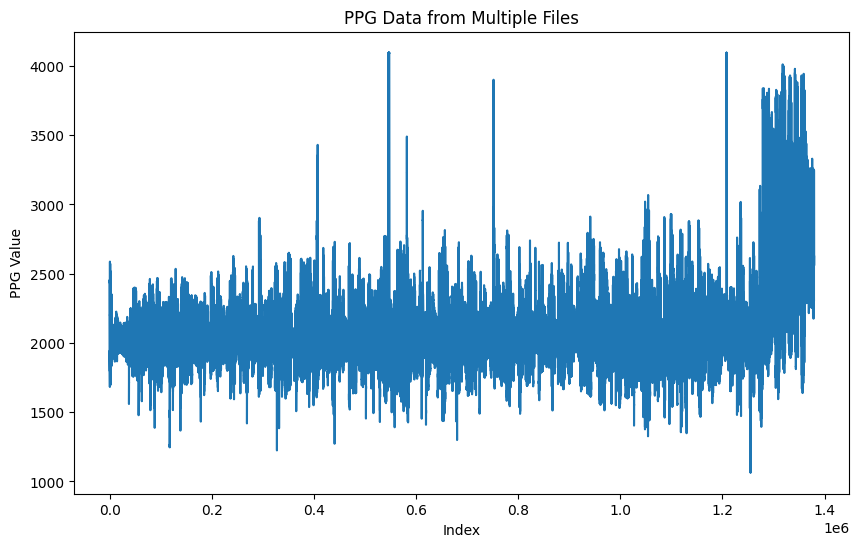

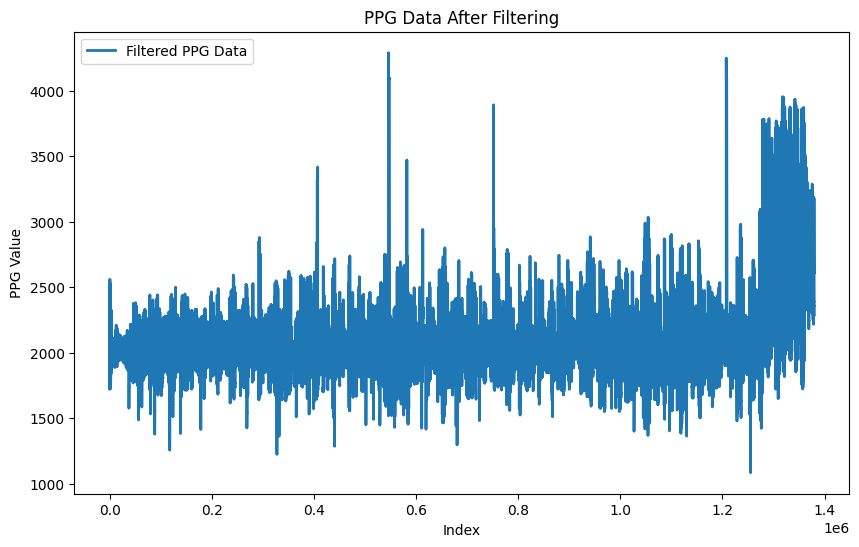

     PPG Value
0  2442.040800
1  2438.044579
2  2434.076153
3  2430.134430
4  2426.218318


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Directory containing the files
directory = r"datasets/5459299\PPG-BP Database\Data File\0_subject"

files_to_concatenate = [f"2_{i}.txt" for i in range(1, 3)] + [f"3_{i}.txt" for i in range(1, 3)]
files_to_concatenate += [f"{i}_{j}.txt" for i in range(4, 421) for j in range(1, 4) if os.path.exists(os.path.join(directory, f"{i}_{j}.txt"))]

concatenated_data = []


for file in files_to_concatenate:
    data = np.loadtxt(os.path.join(directory, file))
    concatenated_data.append(data)

concatenated_data = np.concatenate(concatenated_data)

# Plot the concatenated data
plt.figure(figsize=(10, 6))
plt.plot(range(len(concatenated_data)), concatenated_data)
plt.title("PPG Data from Multiple Files")
plt.xlabel("Index")
plt.ylabel("PPG Value")
plt.show()

# filter using savitzky golay filter
from scipy.signal import savgol_filter
filtered_data = savgol_filter(concatenated_data, 51, 3)

plt.figure(figsize=(10, 6))
plt.plot(range(len(filtered_data)), filtered_data, label="Filtered PPG Data", linewidth=2)
plt.title("PPG Data After Filtering")
plt.xlabel("Index")
plt.ylabel("PPG Value")
plt.legend()
plt.show()

filtered_df = pd.DataFrame(filtered_data, columns=["PPG Value"])
output_path = 'datasets/filtered_data.csv'
filtered_df.to_csv(output_path, index=False)
print(filtered_df.head())
